# Endometriosis Transcriptomics: Initial Data Exploration

## Objective

Identify and evaluate publicly available transcriptomic datasets related to endometriosis for downstream bioinformatics analysis.

## Research Questions

- What tissue types are represented?
- How many endometriosis and control samples are available?
- What transcriptomic platform was used?
- What clinical or phenotype metadata are available?
- Is the dataset suitable for differential gene expression analysis?
- Could the dataset eventually support exploratory biomarker or classification analyses?

## Current Stage

Exploratory data analysis and count-based quality control completed. Formal differential expression and pathway enrichment are performed in the R workflow under `src/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python environment ready.")

Python environment ready.


## Candidate Dataset: GSE153740

**Dataset:** GSE153740  
**Organism:** Homo sapiens  
**Technology:** Bulk RNA sequencing  
**Tissue:** Eutopic endometrium  
**Menstrual phase:** Mid-secretory phase  
**Study groups:** Endometriosis vs. control  
**Sample size:** 8 total samples (4 endometriosis, 4 controls)

### Study Purpose

This dataset was generated to identify transcripts and biological pathways that differ in the eutopic endometrium of women with endometriosis compared with women without endometriosis.

### Why This Dataset

GSE153740 provides a relatively straightforward case-control design using human endometrial tissue and bulk RNA sequencing. This makes it suitable for developing an initial differential-expression workflow while keeping the scope manageable.

### Important Limitation

The dataset contains a small number of biological replicates (n=4 per group), so statistical results should be interpreted cautiously. Findings from this analysis should be considered exploratory rather than clinically validated biomarkers.

## Analysis Plan

This project uses two complementary expression datasets from GSE153740:

1. The submitter-provided transcript-level FPKM matrix is used for initial exploratory analysis, including expression distributions, sparsity assessment, PCA, and sample-to-sample correlation.

2. The NCBI-generated gene-level raw count matrix is used for the formal differential-expression workflow because count-based methods such as DESeq2 require raw counts rather than FPKM values.

The analysis workflow includes:

1. Verify sample identities and endometriosis/control group assignments
2. Inspect expression distributions and sample-level data quality
3. Assess transcript sparsity and sample-to-sample expression patterns
4. Examine raw-count library sizes and low-count gene prevalence
5. Filter genes with insufficient read support
6. Perform variance-stabilizing transformation and PCA using DESeq2
7. Conduct differential gene expression analysis using DESeq2
8. Annotate significant gene-level results
9. Rank genes using DESeq2 Wald statistics
10. Perform ranked gene-set enrichment analysis using MSigDB Hallmark pathways
11. Interpret gene- and pathway-level findings in the context of sample heterogeneity and the small cohort size

Formal differential-expression and pathway-enrichment analyses are implemented in `src/deseq2_analysis.R`.

In [2]:
from pathlib import Path

data_dir = Path("../data/raw")

list(data_dir.glob("*"))

[WindowsPath('../data/raw/GSE153740_GT_SO_7682_7683_Transcript_Expression_Matrix.txt.gz'),
 WindowsPath('../data/raw/GSE153740_raw_counts_GRCh38.p13_NCBI.tsv.gz')]

In [3]:
import gzip

file_path = data_dir / "GSE153740_GT_SO_7682_7683_Transcript_Expression_Matrix.txt.gz"

with gzip.open(file_path, "rt") as f:
    for _ in range(10):
        print(f.readline().rstrip())

Transcript_ID	En1	En2	En3	En6	F10	F14	F15	F9
ENST00000369152	8.1929326795	6.4605212066	18.3733302486	12.5741400177	10.3352100533	10.3479633739	11.5239548828	9.9440381287
ENST00000551855	0	0	0	0	0	0	0	0.1427631163
ENST00000479079	0	0	0	0	0	0.227478178	0	0.2276489398
ENST00000598046	0.8841434224	1.0444640865	0.4612185873	0.000000022	0.1395612424	1.99262E-05	0.2644275909	0.2546926498
ENST00000255409	6.3163187676	5.9986057553	0.5099029176	1.4266625326	0.0803120195	0.0290204288	0.7728934196	6.5661057543
ENST00000515373	0	0.0105584522	0	0	0.1799871847	0	0	0
ENST00000459994	0	0	0	0	0	0	0	0
ENST00000394765	14.2319477947	14.1390780946	35.3863216611	15.080159017	15.7060768724	15.586675284	28.3151149008	31.9097896689
ENST00000406818	0	0	0	0	0	4.667E-07	0.0001385728	0


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
from pathlib import Path

data_dir = Path("../data/raw")

file_path = data_dir / "GSE153740_GT_SO_7682_7683_Transcript_Expression_Matrix.txt.gz"

print(file_path)

..\data\raw\GSE153740_GT_SO_7682_7683_Transcript_Expression_Matrix.txt.gz


In [6]:
expression = pd.read_csv(
    file_path,
    sep="\t",
    compression="gzip"
)

expression.head()

,Transcript_ID,En1,En2,En3,En6,F10,F14,F15,F9
0,ENST00000369152,8.192933,6.460521,18.373330,1.257414e+01,10.335210,10.347963,11.523955,9.944038
1,ENST00000551855,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.142763
2,ENST00000479079,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.227478,0.000000,0.227649
3,ENST00000598046,0.884143,1.044464,0.461219,2.200000e-08,0.139561,0.000020,0.264428,0.254693
4,ENST00000255409,6.316319,5.998606,0.509903,1.426663e+00,0.080312,0.029020,0.772893,6.566106


In [7]:
print("Matrix dimensions:", expression.shape)
print("\nColumn names:")
print(expression.columns.tolist())

print("\nTotal missing values:", expression.isna().sum().sum())
print("Duplicate transcript IDs:", expression["Transcript_ID"].duplicated().sum())

Matrix dimensions: (153794, 9)

Column names:
['Transcript_ID', 'En1', 'En2', 'En3', 'En6', 'F10', 'F14', 'F15', 'F9']

Total missing values: 0
Duplicate transcript IDs: 0


## Initial Data Quality Check

The processed expression matrix contains 153,794 transcript-level observations across 8 biological samples.

Initial inspection showed:

- 153,794 unique transcript IDs
- 8 sample expression columns
- 0 missing values
- 0 duplicate transcript IDs

The next step is to verify sample identities and case-control group assignments using the GEO sample metadata before performing expression-based analyses.

In [8]:
sample_columns = expression.columns[1:]

sample_columns.tolist()

['En1', 'En2', 'En3', 'En6', 'F10', 'F14', 'F15', 'F9']

## Sample Metadata

Sample group assignments were verified against the NCBI GEO metadata for GSE153740.

The dataset contains 8 mid-secretory phase eutopic endometrial samples:

- 4 samples from women with endometriosis
- 4 control samples without endometriosis

A sample metadata table is created below to connect the expression-matrix sample names with their biological groups.

In [9]:
sample_metadata = pd.DataFrame({
    "sample": ["En1", "En2", "En3", "En6",
               "F10", "F14", "F15", "F9"],
    "group": ["Endometriosis", "Endometriosis", "Endometriosis", "Endometriosis",
              "Control", "Control", "Control", "Control"]
})

sample_metadata

,sample,group
0,En1,Endometriosis
1,En2,Endometriosis
2,En3,Endometriosis
3,En6,Endometriosis
4,F10,Control
5,F14,Control
6,F15,Control
7,F9,Control


## Expression Distribution

Before comparing endometriosis and control samples, the distribution of transcript expression values was examined.

Because RNA-seq expression measurements can be strongly right-skewed and may contain many zero or low-expression transcripts, both the raw FPKM values and a log2(FPKM + 1) transformation will be evaluated.

In [10]:
expression_values = expression[sample_columns]

expression_values.describe()

,En1,En2,En3,En6,F10,F14,F15,F9
count,153794.000000,153794.000000,153794.000000,153794.000000,153794.000000,153794.000000,153794.000000,153794.000000
mean,3.689711,3.516091,4.922009,4.431695,5.182432,3.866497,4.219530,4.299449
std,123.098821,124.487258,113.417054,124.785253,337.074777,128.009024,86.852896,91.161380
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.074708,0.082391,0.014365,0.054636,0.000345,0.063227,0.053226,0.000452
75%,0.794586,0.835865,0.627905,0.678808,0.531408,0.861452,0.714256,0.558433
max,22290.385356,23771.176685,17387.248244,30561.244996,90943.507363,27291.829339,14840.816527,14573.896231


In [11]:
log_expression = np.log2(expression_values + 1)

log_expression.describe()

,En1,En2,En3,En6,F10,F14,F15,F9
count,153794.000000,153794.000000,153794.000000,153794.000000,153794.000000,153794.000000,153794.000000,153794.000000
mean,0.654828,0.651491,0.645569,0.654017,0.570466,0.675933,0.665133,0.623015
std,1.139357,1.106532,1.240853,1.214663,1.122139,1.161114,1.221026,1.224980
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.103945,0.114221,0.020577,0.076745,0.000498,0.088450,0.074815,0.000652
75%,0.843651,0.876460,0.703016,0.747438,0.614858,0.896429,0.777583,0.640096
max,14.444199,14.536986,14.085825,14.899463,16.472699,14.736234,13.857380,13.831198


## Sample Expression Distributions

Log2(FPKM + 1) expression distributions were compared across samples to assess overall distributional similarity and identify potential sample-level differences that may warrant further investigation.

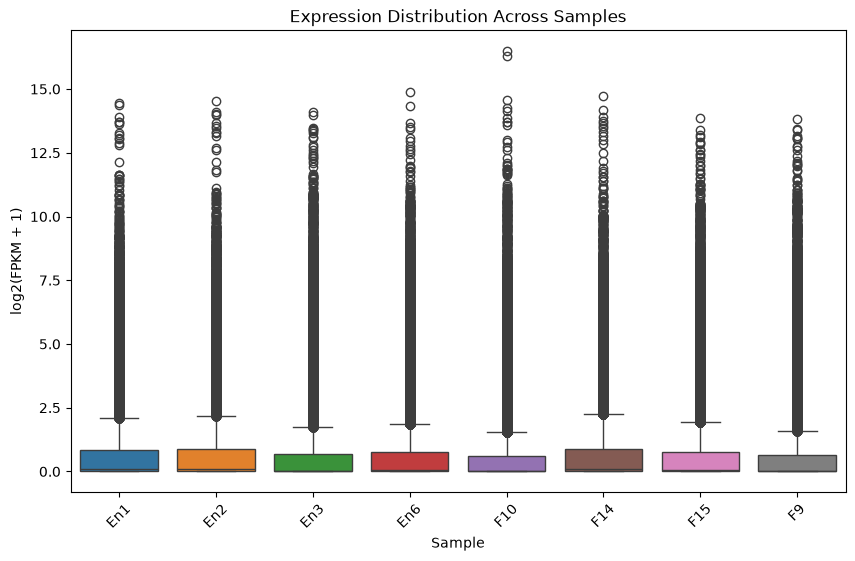

In [12]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=log_expression)

plt.title("Expression Distribution Across Samples")
plt.xlabel("Sample")
plt.ylabel("log2(FPKM + 1)")
plt.xticks(rotation=45)

plt.show()

## Zero-Expression Assessment

The proportion of transcripts with zero measured expression was calculated for each sample to assess sparsity in the processed expression matrix.

In [13]:
zero_percentage = (expression_values == 0).mean() * 100

zero_percentage.round(2)

En1    34.71
En2    34.27
En3    38.73
En6    35.67
F10    40.84
F14    36.18
F15    36.16
F9     40.46
dtype: float64

## Low-Expression Filtering

Transcripts with zero expression across all 8 samples were removed before sample-level exploratory analysis.

This conservative filtering step removes transcripts that contain no expression information in the dataset while avoiding an arbitrary expression threshold at this stage.

In [14]:
expressed_mask = (expression_values > 0).any(axis=1)

filtered_expression = expression_values.loc[expressed_mask].copy()

print("Transcripts before filtering:", expression_values.shape[0])
print("Transcripts after filtering:", filtered_expression.shape[0])
print("Transcripts removed:", expression_values.shape[0] - filtered_expression.shape[0])

Transcripts before filtering: 153794
Transcripts after filtering: 142974
Transcripts removed: 10820


In [15]:
samples_expressed = (expression_values > 0).sum(axis=1)

samples_expressed.value_counts().sort_index()

0    10820
1    17794
2    13372
3    11377
4    10354
5    10265
6    11151
7    14041
8    54620
Name: count, dtype: int64

### PCA Filtering

For sample-level PCA, transcripts were retained if they had nonzero expression in at least 4 of the 8 samples.

This removes highly sparse transcripts while retaining features that may be consistently detected within either biological group. The filtering criterion is used for exploratory sample-level analysis and is not treated as a formal differential-expression threshold.

In [16]:
pca_mask = (expression_values > 0).sum(axis=1) >= 4

pca_expression = expression_values.loc[pca_mask].copy()
pca_log_expression = np.log2(pca_expression + 1)

print("Transcripts before PCA filtering:", expression_values.shape[0])
print("Transcripts after PCA filtering:", pca_expression.shape[0])
print("Transcripts removed:", expression_values.shape[0] - pca_expression.shape[0])

Transcripts before PCA filtering: 153794
Transcripts after PCA filtering: 100431
Transcripts removed: 53363


## Principal Component Analysis

Principal component analysis (PCA) was used to explore overall similarities and differences among the 8 biological samples based on their transcript-expression profiles.

For PCA, the filtered log2(FPKM + 1) matrix was transposed so that samples represent observations and transcripts represent features.

In [ ]:
from sklearn.decomposition import PCA

# Transpose: samples become rows, transcripts become columns
pca_input = pca_log_expression.T

print("PCA input dimensions:", pca_input.shape)

In [ ]:
pca = PCA(n_components=2)

pca_scores = pca.fit_transform(pca_input)

print("Variance explained by PC1:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("Variance explained by PC2:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")

In [ ]:
pca_df = pd.DataFrame(
    pca_scores,
    columns=["PC1", "PC2"],
    index=pca_input.index
)

pca_df = pca_df.reset_index().rename(columns={"index": "sample"})

pca_df = pca_df.merge(sample_metadata, on="sample")

pca_df

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="group",
    s=120
)

for _, row in pca_df.iterrows():
    plt.text(
        row["PC1"] + 0.1,
        row["PC2"] + 0.1,
        row["sample"],
        fontsize=9
    )

plt.xlabel("PC1 (42.06% variance)")
plt.ylabel("PC2 (19.38% variance)")
plt.title("PCA of GSE153740 Transcript Expression")
plt.legend(title="Group")

plt.show()

### PCA Interpretation

PC1 and PC2 explained 42.06% and 19.38% of the total variance, respectively, accounting for 61.44% of the variation across samples.

The first two principal components did not show clear separation between the endometriosis and control groups. Several samples from different groups occupied similar regions of the PCA space, while substantial within-group variability was also observed.

Given the small sample size (n=4 per group), the PCA is treated as an exploratory assessment of sample-level expression patterns rather than evidence of disease-specific clustering.

In [ ]:
sample_correlation = pca_log_expression.corr()

sample_correlation.round(2)

## Sample-to-Sample Correlation

Pairwise Pearson correlations were calculated using the filtered log2(FPKM + 1) expression profiles to assess overall similarity among biological samples.

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    sample_correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=0.75,
    vmax=1.0,
    square=True,
    linewidths=0.5
)

plt.title("Sample-to-Sample Expression Correlation")
plt.tight_layout()
plt.show()

### Correlation Interpretation

Pairwise sample correlations were generally high, ranging from approximately 0.77 to 0.94.

However, the correlation structure did not align consistently with disease status. Some endometriosis samples showed strong similarity to control samples, while variability was also observed among samples within the same group.

Together with the PCA results, these findings suggest substantial sample-level heterogeneity and do not support clear global transcriptomic separation between endometriosis and control samples in this small cohort.

## NCBI-Generated Raw Gene Counts

For formal differential-expression analysis, an NCBI-generated raw gene-count matrix for GSE153740 was obtained.

Unlike the submitter-supplied transcript-level FPKM matrix used for exploratory analysis, this dataset contains gene-level raw counts and is intended for count-based downstream analyses.

The structure and contents of the count matrix are inspected below before further processing.

In [ ]:
raw_counts_file = data_dir / "GSE153740_raw_counts_GRCh38.p13_NCBI.tsv.gz"

with gzip.open(raw_counts_file, "rt") as f:
    for _ in range(10):
        print(f.readline().rstrip())

In [ ]:
raw_counts = pd.read_csv(
    raw_counts_file,
    sep="\t",
    compression="gzip"
)

print("Matrix dimensions:", raw_counts.shape)

print("\nColumn names:")
print(raw_counts.columns.tolist())

print("\nTotal missing values:", raw_counts.isna().sum().sum())

print("Duplicate GeneIDs:", raw_counts["GeneID"].duplicated().sum())

raw_counts.head()

### Raw Count Sample Metadata

The NCBI-generated count matrix uses GEO Sample (GSM) accession numbers as column identifiers. These accessions were mapped to the original study sample labels and biological groups using the GSE153740 sample metadata.

The dataset contains 4 endometriosis and 4 control samples.

In [ ]:
count_metadata = pd.DataFrame({
    "GSM": [
        "GSM4650386",
        "GSM4650387",
        "GSM4650388",
        "GSM4650389",
        "GSM4650390",
        "GSM4650391",
        "GSM4650392",
        "GSM4650393"
    ],
    "sample": [
        "En1",
        "En2",
        "En3",
        "En6",
        "F10",
        "F14",
        "F15",
        "F9"
    ],
    "group": [
        "Endometriosis",
        "Endometriosis",
        "Endometriosis",
        "Endometriosis",
        "Control",
        "Control",
        "Control",
        "Control"
    ]
})

count_metadata

In [ ]:
count_columns = raw_counts.columns[1:].tolist()

assert count_columns == count_metadata["GSM"].tolist()

print("Sample metadata matches count matrix columns.")

## Raw Count Quality Control

Before differential-expression analysis, sequencing library sizes were examined across samples.

Library size represents the total number of gene-level counts observed for each sample. Differences in library size are expected in RNA-seq data and will later be accounted for through appropriate normalization.

In [ ]:
count_matrix = raw_counts.drop(columns="GeneID")

library_sizes = count_matrix.sum(axis=0)

library_sizes

In [ ]:
library_size_df = count_metadata.copy()

library_size_df["library_size"] = library_size_df["GSM"].map(library_sizes)

library_size_df

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=library_size_df,
    x="sample",
    y="library_size",
    hue="group",
    dodge=False
)

plt.title("RNA-seq Library Size Across Samples")
plt.xlabel("Sample")
plt.ylabel("Total Raw Counts")

plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Group")
plt.tight_layout()

plt.show()

### Low-Count Gene Assessment

The distribution of low-count genes was examined before differential-expression analysis.

Genes with very low read counts across most samples provide limited statistical information. Their prevalence was assessed before defining a filtering criterion for the count-based differential-expression workflow.

In [ ]:
genes_by_sample_count = pd.Series({
    "Zero in all samples": (count_matrix.sum(axis=1) == 0).sum(),
    "Count >= 10 in at least 1 sample": (count_matrix >= 10).any(axis=1).sum(),
    "Count >= 10 in at least 4 samples": ((count_matrix >= 10).sum(axis=1) >= 4).sum(),
    "Count >= 10 in all 8 samples": (count_matrix >= 10).all(axis=1).sum()
})

genes_by_sample_count

### Low-Count Gene Filtering

Genes were retained for downstream differential-expression analysis if they had at least 10 raw counts in at least 4 of the 8 samples.

This criterion removes genes with consistently low read support while allowing genes that may be expressed predominantly within either the endometriosis or control group to remain in the analysis.

In [ ]:
keep_genes = (count_matrix >= 10).sum(axis=1) >= 4

filtered_counts = raw_counts.loc[keep_genes].copy()

print("Genes before filtering:", raw_counts.shape[0])
print("Genes after filtering:", filtered_counts.shape[0])
print("Genes removed:", raw_counts.shape[0] - filtered_counts.shape[0])